### **2. Técnicas de Redução da Dimensionalidade: Análise de Componentes Principais (PCA)** 

#### Autor: Tony Esaú de Oliveira.

##### Universidade Federal do Cariri


#### **Maldição da Dimensionalidade**

A maldição da dimensionalidade refere-se às severas dificuldades que surgem quando se trabalha com espaços que possuem muitas dimensões. À medida que a dimensionalidade ($D$) é aumentada, o número de regiões em uma grade regular cresce exponencialmente, tornando-se impraticável preencher esses espaços com dados suficientes para análises estatísticas. Geometricamente, as intuições desenvolvidas em três dimensões falham em espaços dimensionais superiores; por exemplo, em altas dimensões, a maior parte do volume de uma esfera concentra-se em uma casca fina perto de sua superfície e a massa de uma distribuição Gaussiana concentra-se em um anel fino a uma certa distância da origem.

#### **Redução de Dimensionalidade**

A redução de dimensionalidade é o processo de alterar a representação de dados complexos, originalmente descritos por um grande número de variáveis, para uma descrição de baixa dimensão usando apenas um pequeno número de parâmetros livres. Essa técnica pode ser implementada por meio de duas abordagens principais:

- **Seleção de atributos:** Identifica e seleciona o menor subconjunto de variáveis originais que melhor representam as características essenciais do problema, descartando as irrelevantes ou redundantes;
- **Extração de atributos:** Realiza transformações matemáticas ou combinações das variáveis originais para criar novas representações (como no método PCA), mantendo o máximo de informação possível em um número menor de dimensões.

A importância da redução de dimensionalidade reside em diversos fatores práticos e teóricos:

- **Eficiência Computacional e de Armazenamento:** Com a geração exponencial de dados (*Big Data*), a redução diminui a necessidade de espaço em disco e acelera drasticamente o tempo de processamento dos algoritmos;
- **Melhoria de Desempenho:** Ao eliminar redundâncias e ruídos ("informações irrelevantes"), as técnicas ajudam a evitar o sobreajuste (*overfitting*), permitindo que modelos de aprendizado de máquina alcancem maior precisão e generalização;
- **Visualização de Dados:** Projetar dados de alta dimensão em espaços de duas ou três dimensões permite que humanos visualizem estruturas, agrupamentos e padrões ocultos de forma intuitiva;
- **Estrutura Intrínseca:** Dados reais frequentemente residem em variedades não lineares (*manifolds*) de baixa dimensão embutidas no espaço de alta dimensão; a redução permite explorar essa estrutura efetiva inferior.

---

#### **Human Activity Recognition with Smartphones**

##### **Visão Geral**
- Classificação de atividades humanas (andar, sentar, etc.);
- ~3.000 amostras;
- 561 features;
- Dados de sensores de smartphone (acelerômetro e giroscópio).

##### **Origem dos Dados**
Sensores usados:
- Acelerômetro: movimento linear;
- Giroscópio: rotação.

Obs.: Celular posicionado na cintura dos usuários.

##### **Estrutura das Features**

Formato geral:

[t/f][Body/Gravity][Acc/Gyro]-[estatística]-[eixo]

##### **Componentes**

- **t / f**  
  - `t`: domínio do tempo;
  - `f`: domínio da frequência.

- **Tipo de sinal**  
  - `BodyAcc`: aceleração do corpo; 
  - `GravityAcc`: gravidade;
  - `BodyGyro`: rotação.

- **Estatísticas**  
  - `mean()`: média;
  - `std()`: desvio padrão; 
  - `energy()`: energia;
  - `entropy()`: entropia. 

- **Eixos**  
  - `X`, `Y`, `Z`


##### **Exemplo**

- `tBodyAcc-mean()-X`: média da aceleração no eixo X;  
- `fBodyGyro-energy()-Z`: energia do giroscópio no eixo Z.

##### Intuição

- Cada linha: um intervalo de movimento;
- Cada coluna: uma característica desse movimento. 

---

#### **Análise de Componentes Principais (PCA)**

A Análise de Componentes Principais (PCA) é uma técnica estatística clássica e amplamente utilizada para a redução de dimensionalidade e extração de informações relevantes em conjuntos de dados multivariados. Formalmente, o PCA é definido como a projeção ortogonal dos dados em um espaço linear de dimensão inferior, conhecido como **subespaço principal**, de tal forma que a variância dos dados projetados seja maximizada. Equivalentemente, ele pode ser definido como a projeção linear que minimiza o custo médio de projeção, ou seja, a distância quadrática média entre os pontos de dados originais e suas projeções. Além disso, o PCA é um algoritmo de aprendizado não supervisionado, o que significa que ele identifica padrões e estruturas nos dados sem levar em conta rótulos de classe. Ele transforma um conjunto de variáveis possivelmente correlacionadas em um conjunto menor de variáveis lineares não correlacionadas, chamadas de **componentes principais**.

A aplicação do PCA segue um processo matemático estruturado que envolve a análise da estrutura de variância dos dados:

1. **Pré-processamento (Centralização)**: O primeiro passo consiste em calcular a média $\overline{x}$ do conjunto de dados e subtraí-la de cada vetor de observação, garantindo que os dados tenham média zero;
2. **Cálculo da Matriz de Covariância**: Calcula-se a matriz de covariância $S$ do conjunto de dados, que mede as relações lineares entre os atributos.
3. **Decomposição em Autovetores e Autovalores**: A matriz de covariância é diagonalizada para encontrar seus autovetores e autovalores associados.
    - Os autovetores representam as direções dos eixos principais (as direções de maior variação);
    - Os autovalores indicam a magnitude da variância explicada por cada componente correspondente.
4. **Seleção de Componentes**: Os componentes principais são ordenados de forma decrescente de acordo com seus autovalores. Escolhe-se um número $M$ de componentes (onde $M<D$) que preservem a maior parte da variância original (por exemplo, retendo $95\%$ ou $99\%$ da variância);
5. **Projeção**: Os dados originais são transformados e projetados no novo espaço de baixa dimensão definido pelos $M$ autovetores selecionados.

---

In [1]:
import pandas as pd 
import numpy as np

In [2]:
dados = pd.read_csv('Conjunto_Dados/Human_Activity_Recognition_with_Smartphones.csv')

In [3]:
dados.head(10)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING
5,0.279220,-0.018620,-0.113902,-0.994455,-0.970417,-0.965316,-0.994585,-0.969481,-0.965897,-0.937856,...,-0.857565,-0.095681,0.048849,0.760684,-0.072216,-0.689816,0.294896,-0.068471,2,STANDING
6,0.279746,-0.018271,-0.104000,-0.995819,-0.976354,-0.977725,-0.995996,-0.973665,-0.979253,-0.937856,...,-0.391286,-0.309083,-0.000857,0.728514,-0.333771,-0.690085,0.295282,-0.067065,2,STANDING
7,0.274601,-0.025035,-0.116831,-0.995594,-0.982069,-0.985262,-0.995341,-0.981485,-0.984610,-0.941263,...,-0.672358,-0.025526,-0.214033,0.437640,-0.366674,-0.688785,0.295981,-0.067706,2,STANDING
8,0.272529,-0.020954,-0.114472,-0.996784,-0.975906,-0.986597,-0.997029,-0.973735,-0.985556,-0.941263,...,-0.853248,0.144626,-0.035564,-0.181800,0.087320,-0.685390,0.299394,-0.065491,2,STANDING
9,0.275746,-0.010372,-0.099776,-0.998373,-0.986933,-0.991022,-0.998663,-0.987140,-0.991084,-0.943761,...,-0.741435,0.157584,-0.033487,-0.350893,0.343146,-0.684110,0.300822,-0.064263,2,STANDING


In [4]:
dados.shape

(2947, 563)

In [5]:
dados['Activity'].unique()

mapa = {
    'STANDING': 0,
    'SITTING': 1,
    'WALKING_DOWNSTAIRS': 2,
    'LAYING': 3,
    'WALKING': 4,
    'WALKING_UPSTAIRS': 5
}

dados['Activity'] = dados['Activity'].map(mapa)

---

#### **Aplicação de PCA**

In [6]:
# Separando os dados em features (X) e rótulos (y). 
from sklearn.model_selection import train_test_split
# StandrdScaler para padronização dos dados.
from sklearn.preprocessing import StandardScaler
# PCA para redução de dimensionalidade.
from sklearn.decomposition import PCA

X = dados.drop(columns=["Activity"])
y = dados["Activity"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

In [7]:
# O PCA é sensível à escala dos dados, então é fundamental padronizar as features para que cada uma tenha média zero e desvio padrão um.
scaler = StandardScaler()
# Ajustando o scaler apenas nos dados de treinamento e transformando ambos os conjuntos.
X_treino_scaled = scaler.fit_transform(X_treino)
# Transformando os dados de teste usando o mesmo scaler ajustado nos dados de treinamento.
X_test_scaled = scaler.transform(X_teste)

In [8]:
"""
    - Aplicando PCA para redução de dimensionalidade, mantendo 95% da variância explicada.
    - O número de componentes será escolhido automaticamente para atingir esse objetivo.
"""
pca = PCA(n_components=0.95)  

# Ajustando o PCA nos dados de treinamento e transformando ambos os conjuntos.
X_treino_pca = pca.fit_transform(X_treino_scaled)
# Transformando os dados de teste usando o mesmo PCA ajustado nos dados de treinamento.
X_test_pca = pca.transform(X_test_scaled)

print("Número original de features:", X_treino.shape[1])
print("Número reduzido de componentes:", X_treino_pca.shape[1])
print("Variância explicada total:", sum(pca.explained_variance_ratio_))

Número original de features: 562
Número reduzido de componentes: 99
Variância explicada total: 0.9506744093393341


In [9]:
dados_reduzido = pd.DataFrame(X_treino_pca, columns=[f'PC{i+1}' for i in range(X_treino_pca.shape[1])])
dados_reduzido 

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC90,PC91,PC92,PC93,PC94,PC95,PC96,PC97,PC98,PC99
0,-15.911561,1.165514,-0.236994,2.518263,1.148091,-2.755160,0.322973,1.432486,0.659099,-1.591760,...,0.355934,-1.408275,-0.484558,0.145185,0.108378,0.616760,0.035723,0.483647,-0.477168,-0.003760
1,-11.566227,-8.011830,1.581854,0.179670,0.415924,0.289909,2.746778,-5.255404,-0.923312,-0.474441,...,-0.331920,2.186805,-0.711198,-0.106957,0.551741,-0.217424,-1.308786,0.437299,0.576036,-1.722004
2,-16.455988,7.155582,-1.277104,-4.503405,-1.264605,5.281846,-1.998914,1.211333,-0.719858,1.291118,...,-1.234404,0.629380,-1.027942,0.276031,-0.504886,0.416254,0.641475,-1.026958,-0.770995,0.345876
3,8.600982,0.300618,8.065797,3.653442,-3.665260,2.084936,-0.240770,0.887832,3.561640,0.261209,...,0.488347,-0.597330,-0.828893,-0.602336,-0.432368,1.172884,0.065989,-0.746081,-0.230505,-0.293501
4,24.375524,10.607581,3.956835,2.504378,0.911158,0.410528,1.274361,0.235759,3.521884,-1.758225,...,-0.174270,0.387964,-0.941876,0.928315,-1.744117,-0.799997,-0.439918,0.293240,0.202607,0.162199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2647,-4.847790,-7.432224,-0.313227,4.605029,1.434419,2.525396,2.949679,-2.088087,0.777339,2.760017,...,1.864366,0.049367,-0.516435,-0.026602,0.033508,0.082431,-0.792391,-0.114436,-0.362750,-1.085333
2648,-16.341070,0.707571,1.301536,0.327671,1.548917,-3.155271,0.759409,-0.038505,1.315576,-0.388450,...,-0.489987,-0.846200,1.040859,-0.075160,-0.945341,-0.590329,0.217772,0.097728,0.320159,-0.556374
2649,-17.094007,6.164252,-0.409565,0.114288,0.420366,-1.485061,-1.493838,1.472974,-2.306623,0.886155,...,0.606851,-0.364756,0.486229,-1.327216,-0.149555,-0.236511,-0.045245,2.129307,0.620522,-0.722404
2650,-15.899952,-1.073163,1.170883,1.824972,1.928664,-3.976902,1.013243,-1.489260,0.063631,-2.357873,...,-1.030776,1.046062,0.014475,0.984537,0.338480,0.728382,-0.048294,-0.644892,1.497033,-0.101032


#### Gráfico de Cotovelo
O *Scree Plot* (ou Gráfico de Cotovelo) é uma ferramenta visual utilizada para decidir quantas componentes principais ou fatores você deve manter em uma análise de redução de dimensionalidade, como o PCA. Para utilizá-lo devemos manter o espectro completo de informações com todas as componentes possíveis.

In [14]:
# Ajustando o PCA nos dados de treinamento para análise da variância explicada.
pca = PCA()
pca.fit(X_treino_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [15]:
# Calculando a variância acumulada para cada componente principal.
variancia_acumulada = np.cumsum(pca.explained_variance_ratio_)

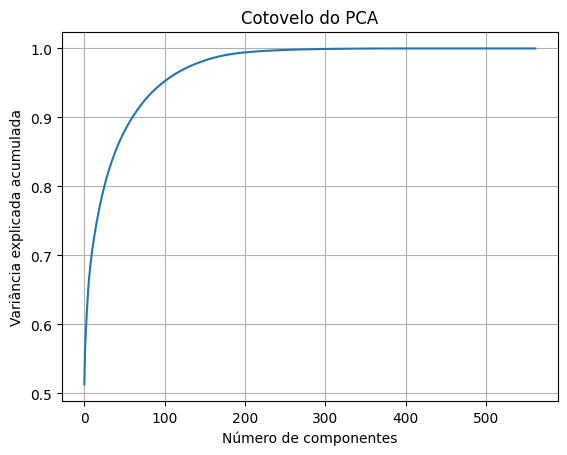

In [16]:
# Plotando a variância explicada acumulada para visualizar o "cotovelo" do PCA.
import matplotlib.pyplot as plt

plt.figure()
plt.plot(variancia_acumulada)
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada")
plt.title("Cotovelo do PCA")
plt.grid()
plt.show()

In [ ]:
# Determinando o número mínimo de componentes necessários para atingir 95% da variância explicada.
k_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
k_95

np.int64(99)

---

Algumas observações sobre PCA:

1. **Centralização (obrigatória)**

- O PCA sempre subtrai a média das variáveis. Isso já é parte interna dele, mas é bom garantir que não tem bagunça nos dados.

2. **Padronização**

- Se suas features têm escalas diferentes (ex: uma vai de 0 a 1 e outra de 0 a 10000), o PCA vai dar mais importância pra maior escala. Então normalmente se usa:

    `from sklearn.preprocessing import StandardScaler
    X_scaled = StandardScaler().fit_transform(X)`

3. **Tratamento de *Outliers***

- *Outliers* distorcem a variância, e como PCA depende disso, ele pode “puxar” os componentes principais pro lugar errado.

4. **Remoção de features muito ruins/redundantes**

    Antes do PCA, às vezes vale:

    - Tirar colunas constantes;
    - Tirar colunas quase iguais (alta correlação);
    - Isso melhora estabilidade.